In [1]:
# Copyright (C) 2024 Richard Stiskalek
# This program is free software; you can redistribute it and/or modify it
# under the terms of the GNU General Public License as published by the
# Free Software Foundation; either version 3 of the License, or (at your
# option) any later version.
#
# This program is distributed in the hope that it will be useful, but
# WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the GNU General
# Public License for more details.
#
# You should have received a copy of the GNU General Public License along
# with this program; if not, write to the Free Software Foundation, Inc.,
# 51 Franklin Street, Fifth Floor, Boston, MA  02110-1301, USA.
from os.path import exists
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
from scipy.interpolate import interp1d
from os.path import join


import sys
sys.path.append("../")

from reconstruction_comparison import *

%load_ext autoreload
%autoreload 2
%matplotlib inline

In [350]:
RA_coma = csiborgtools.hms_to_degrees(12, 59, 48.7)
dec_coma = csiborgtools.dms_to_degrees(27, 58, 50)

rhat = csiborgtools.radec_to_cartesian(np.asarray([1, RA_coma, dec_coma]).reshape(1, 3))

In [ ]:
fdir = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_calibrated"

profiles = ["exp", "mb"]

logZ = []

for profile in profiles:
    fname = join(fdir, f"samples_IndranilVoidSizeVar_{profile}_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_sample_beta_which_void_size_run_zoom_remove_CF4_outliers.hdf5")
    logZ.append(get_gof("logZ_harmonic", fname))


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_calibrated/samples_IndranilVoidSizeVar_exp_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_which_void_size_run_zoom_remove_CF4_outliers.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [474]:
def get_vrad(profile):
    # fname = f"/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_calibrated/samples_IndranilVoidSizeVar_{profile}_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_which_void_size_run_zoom_remove_CF4_outliers.hdf5"
    fname = f"/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_calibrated/samples_IndranilVoidSizeVar_{profile}_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_sample_beta_which_void_size_run_zoom_remove_CF4_outliers.hdf5"
    # fname = f"/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_calibrated/samples_IndranilVoidSizeVar_{profile}_CF4_TFR_i_CF4_TFR_notSDSS_w1_bayes_zcmb_max_0.05_which_void_size_run_zoom_remove_CF4_outliers.hdf5"

    samples = get_some_samples(fname, ["Vext_cartesian", "void_size", "rLG", "beta"])


    size_grid, rLG_grid, vrad_grid = csiborgtools.flow.load_void_size_variation(profile, "vrad", "zoom")

    void_size_min = size_grid.min()
    void_size_max = size_grid.max()

    


    rgrid_min = 0
    rgrid_max = 400

    rLG_min = rLG_grid.min()
    rLG_max = rLG_grid.max()

    x_grid, y_grid = csiborgtools.flow.select_void_h(None, profile, return_all=True)
    h_void_func = interp1d(x_grid / 100, y_grid, bounds_error=False, fill_value="extrapolate")

    # print("beta mean ", samples["beta"].mean())
    print("size mean ", samples["void_size"].mean())

    r2zcosmo = csiborgtools.flow.ComovingDistance2Redshift(0.3,)
    r = np.linspace(0, 150, 100)

    vrad = []
    for n in range(2500):
        try:
            void_size = samples["void_size"][n]
        except KeyError:
            void_size = 1.
        rLG = samples["rLG"][n]
        Vext = samples["Vext"][n]
        try:
            beta = samples["beta"][n]
        except KeyError:
            beta = 1.0
        h_void = h_void_func(void_size)

        Vext_rad = np.sum(Vext * rhat[0])

        vrad_ = csiborgtools.flow.interpolate_size_var_void(
            void_size, rLG, h_void, Vext, r, rhat, vrad_grid,
            void_size_min, void_size_max, rgrid_min, rgrid_max, rLG_min, rLG_max,
            )[0]
        vrad.append(beta * vrad_ + Vext_rad)


    vrad = np.asarray(vrad)
    return r, vrad




In [ ]:
profile = "mb"
fname = f"/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_calibrated/samples_IndranilVoidSizeVar_{profile}_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_sample_beta_which_void_size_run_zoom_remove_CF4_outliers.hdf5"
# fname = f"/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_calibrated/samples_IndranilVoidSizeVar_{profile}_CF4_TFR_i_CF4_TFR_notSDSS_w1_bayes_zcmb_max_0.05_which_void_size_run_zoom_remove_CF4_outliers.hdf5"

samples = get_some_samples(fname, ["Vext_cartesian", "void_size", "rLG", "beta"])

In [473]:
np.linalg.norm(samples["Vext"], axis=1).mean()

678.7656

In [475]:
r, vrad_mb = get_vrad("mb")
# r, vrad_gauss = get_vrad("gauss")
# r, vrad_exp = get_vrad("exp")

2025-04-13 01:09:28,368 loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_newDecember/processed_mb_vrad.hdf5`.
size mean  0.1497686


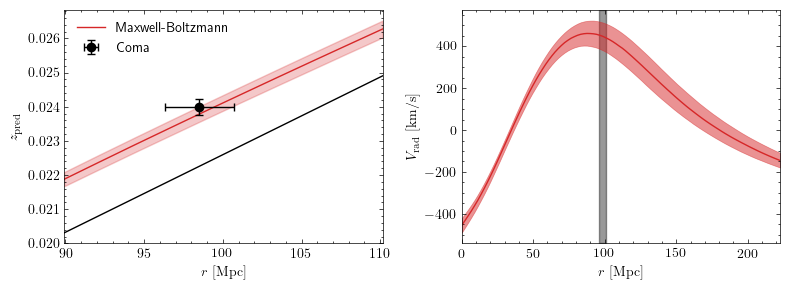

In [477]:
SPEED_OF_LIGHT = 299_792.458  # km/s

# Cosmological conversion
r2zcosmo = csiborgtools.flow.ComovingDistance2Redshift(0.3)
zcosmo = r2zcosmo(r)

# Cluster properties
h_void_here = 0.6740
r_coma = 98.5       # Mpc
e_r_coma = 2.2      # Mpc
# zcoma = 0.02445  
zcoma = 0.024

e_zcoma = 0.00024


# Select physical radial range
r_phys = r / h_void_here
rmask = np.abs(r_phys - r_coma) < 15
r_fixed = r_phys[rmask]

# vrads = [vrad_exp, vrad_gauss, vrad_mb]
# labels = ["Exponential", "Gaussian", "Maxwell-Boltzmann"]
vrads = [vrad_mb]
labels = ["Maxwell-Boltzmann"]
cols = ["#d62728", "#1f77b4", "gray"]

# --- Begin subplot setup ---
with plt.style.context("science"):
    fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=False)
    # cols = plt.rcParams['axes.prop_cycle'].by_key()['color']

    # ---- Left Plot: r vs z_pred (switched axes) ----
    ymeds, ylows, yhighs = [], [], []
    for vrad in vrads:
        zpred = (1 + zcosmo[None, :]) * (1 + vrad / SPEED_OF_LIGHT) - 1
        ylow, ymed, yhigh = np.percentile(zpred, [16, 50, 84], axis=0)

        ym = ymed[rmask]
        yl = ylow[rmask]
        yh = yhigh[rmask]

        ymeds.append(ym)
        ylows.append(yl)
        yhighs.append(yh)

    ymeds = np.array(ymeds)
    ylows = np.array(ylows)
    yhighs = np.array(yhighs)

    zmask = np.any(np.abs(ymeds - zcoma) < 10 * e_zcoma, axis=0)

    for i, (ym, yl, yh, label) in enumerate(zip(ymeds, ylows, yhighs, labels)):
        axs[0].plot(r_fixed[zmask], ym[zmask], label=label, color=cols[i])
        axs[0].fill_between(r_fixed[zmask], yl[zmask], yh[zmask], alpha=0.25, color=cols[i])

    axs[0].plot(r_fixed[zmask], zcosmo[rmask][zmask],c="k") 

    axs[0].errorbar(r_coma, zcoma, xerr=e_r_coma, yerr=e_zcoma,
                    fmt="o", color="k", label="Coma", capsize=3)
    axs[0].set_xlabel(r"$r ~ [\mathrm{Mpc}]$")
    axs[0].set_ylabel(r"$z_{\rm pred}$")
    axs[0].set_xlim(r_fixed[zmask].min(), r_fixed[zmask].max())
    axs[0].legend(frameon=False)

    # ---- Right Plot: v_rad profile vs r ----
    for i, (vrad, label) in enumerate(zip(vrads, labels)):
        ylow, ymed, yhigh = np.percentile(vrad, [16, 50, 84], axis=0)
        axs[1].plot(r / h_void_here, ymed, label=label, color=cols[i])
        axs[1].fill_between(r / h_void_here, ylow, yhigh, alpha=0.5, color=cols[i], linewidth=0.5)
    
    axs[1].set_xlabel(r"$r ~ [\mathrm{Mpc}]$")
    axs[1].set_ylabel(r"$V_{\rm rad} ~ [\mathrm{km} / \mathrm{s}]$")
    axs[1].set_xlim(r.min() / h_void_here, r.max() / h_void_here)
    # Add vertical bars for coma
    ylim = axs[1].get_ylim()
    axs[1].fill_betweenx(
        ylim, r_coma - e_r_coma, r_coma + e_r_coma,
        color="black", alpha=0.4, label="Coma", zorder=-1)
    axs[1].set_ylim(*ylim)

    fig.tight_layout()
    fig.show()

